# Review Comment Analysis

## BUSINESS CASE

1. Berapa persentase order yang memberikan review comment vs yang tidak?
2. Apakah pelanggan dengan review score rendah (1–2) lebih cenderung menulis komentar?
3. Berapa rata-rata waktu antara order_delivered dan review_creation_date?


## IMPORT LIBRARY

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

## GATHERING DATA 

In [2]:
order = pd.read_csv('https://raw.githubusercontent.com/adinfir/data-new/refs/heads/main/E-commerce-public-dataset/orders_dataset.csv')
order_review = pd.read_csv('https://raw.githubusercontent.com/adinfir/data-new/refs/heads/main/E-commerce-public-dataset/order_reviews_dataset.csv')

## DATA UNDERSTANDING

In [3]:
order.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
order_review.head(5)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


### GRAIN

1. tabel order : 1 row merepresntasikan 1 order
2. tabel order_review : 1 row merepresentasikan 1 review

### KEY COLUMN

1. **Tabel `order`**:
   - `order_id` → identifier untuk setiap order
   - `order_delivered_customer_date` → waktu saat customer menerima order

2. **Tabel `order_review`**:
   - `order_id` → identifier untuk setiap order,digunakan untuk menghubungkan `order_review` dengan `order
   - `review_score` → score review untuk tiap order
   - `review_comment_message` → comment review untuk tiap order
   - `review_creation_date` → waktu saat customer membuat review
   

### RELATIONSHIP TABLE

- Tabel `order_review` dan `order` terhubung melalui `order_id`.

- `order` memiliki hubungan **one-to-many** (1:M) dengan `order_review`, karena satu order dapat memiliki lebih dari satu record review. .    

## QUALITY DATA

### ASESSING DATA

In [5]:
order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


1. Untuk kolom ```order_purchase_timestamp```,```order_approved_at```, ```order_delivered_carrier_date```, ```order_delivered_customer_date```,```order_estimated_delivery_date``` masih berbentuk object belum datetime

In [6]:
order.describe(include='all')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [7]:
print('Checking null value')
order.isna().sum()

Checking null value


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

1.  Untuk kolom ```order_approved_at```, ```order_delivered_carrier_date```, ```order_delivered_customer_date``` terdapat missing value

In [8]:
print('Checking duplicated value')
order.duplicated().sum()

Checking duplicated value


0

In [9]:
order_review.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


1. Untuk kolom ```review_creation_date```dan```review_answer_timestamp``` masih berbentuk object belum datetime

In [10]:
order_review.describe(include='all')

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
count,99224,99224,99224.000000,11568,40977,99224,99224
unique,98410,98673,NaN,4527,36159,636,98248
top,7b606b0d57b078384f0b58eac1d41d78,c88b1d1b157a9999ce368f218a407141,NaN,Recomendo,Muito bom,2017-12-19 00:00:00,2017-06-15 23:21:05
freq,3,3,NaN,423,230,463,4
mean,NaN,NaN,4.086421,NaN,NaN,NaN,NaN
std,NaN,NaN,1.347579,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN


In [11]:
print('Checking null value')
order_review.isna().sum()

Checking null value


review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

1.  Untuk kolom ```review_comment_message```, ```review_comment_title``` terdapat missing value

In [12]:
print('Checking duplicated value')
order_review.duplicated().sum()

Checking duplicated value


0

In [13]:
print('Checking duplicated value order_id')
order_review['order_id'].duplicated().sum()

Checking duplicated value order_id


551

Pada tabel order_reviews ditemukan beberapa order_id yang memiliki lebih dari satu review record. Kondisi ini perlu diperhatikan karena order_id tidak selalu merepresentasikan satu review record.

### CLEANING DATA

## DATA PREAPARATION

### MENGUBAH TIPE DATA PADA TABEL ORDER

mengubah kolom ```order_purchase_timestamp```,```order_approved_at```, ```order_delivered_carrier_date```, ```order_delivered_customer_date```,```order_estimated_delivery_date``` menjadi daatetime

In [14]:
order['order_purchase_timestamp'] = pd.to_datetime(order['order_purchase_timestamp'])
order['order_approved_at'] = pd.to_datetime(order['order_approved_at'])
order['order_delivered_carrier_date'] = pd.to_datetime(order['order_delivered_carrier_date'])
order['order_delivered_customer_date'] = pd.to_datetime(order['order_delivered_customer_date'])
order['order_estimated_delivery_date'] = pd.to_datetime(order['order_estimated_delivery_date'])

### MENGUBAH TIPE DATA PADA TABEL ORDER_REVIEW

mengubah kolom ```review_creation_date```, ```review_answer_timestamp``` menjadi daatetime

In [15]:
order_review['review_creation_date'] = pd.to_datetime(order_review['review_creation_date'])
order_review['review_answer_timestamp'] = pd.to_datetime(order_review['review_answer_timestamp'])

**CATATAN:** Terdapat **768 order** yang tidak memiliki `review_score`. Karena `review_score` digunakan sebagai bagian dari analisis, data tersebut tidak dapat digunakan dalam proses EDA. Oleh karena itu, dilakukan treatment dengan **menghapus 768 data tersebut** dari analisis.


## EXPLORATORY DATA ANALYSIS

### 1. Berapa persentase order yang memberikan review comment vs yang tidak?

In [16]:
data_q1 = order_review[['order_id','review_comment_message']]

In [17]:
#MEMBERI LABEL PADA REVIEW COMMENT MESSAGE
data_q1['label'] = np.where(data_q1['review_comment_message'].isna(), 'Tidak memberi comment review', 'Memberi comment review')

C:\Users\adien\AppData\Local\Temp\ipykernel_8696\4065442546.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_q1['label'] = np.where(data_q1['review_comment_message'].isna(), 'Tidak memberi comment review', 'Memberi comment review')


In [18]:
data_q1_clean = data_q1.groupby(by='label')['order_id'].count().reset_index()
data_q1_clean

,label,order_id
0,Memberi comment review,40977
1,Tidak memberi comment review,58247


In [19]:
grand_total = data_q1_clean['order_id'].sum()
data_q1_clean['pct'] = data_q1_clean['order_id'] / grand_total * 100
data_q1_clean

,label,order_id,pct
0,Memberi comment review,40977,41.297468
1,Tidak memberi comment review,58247,58.702532


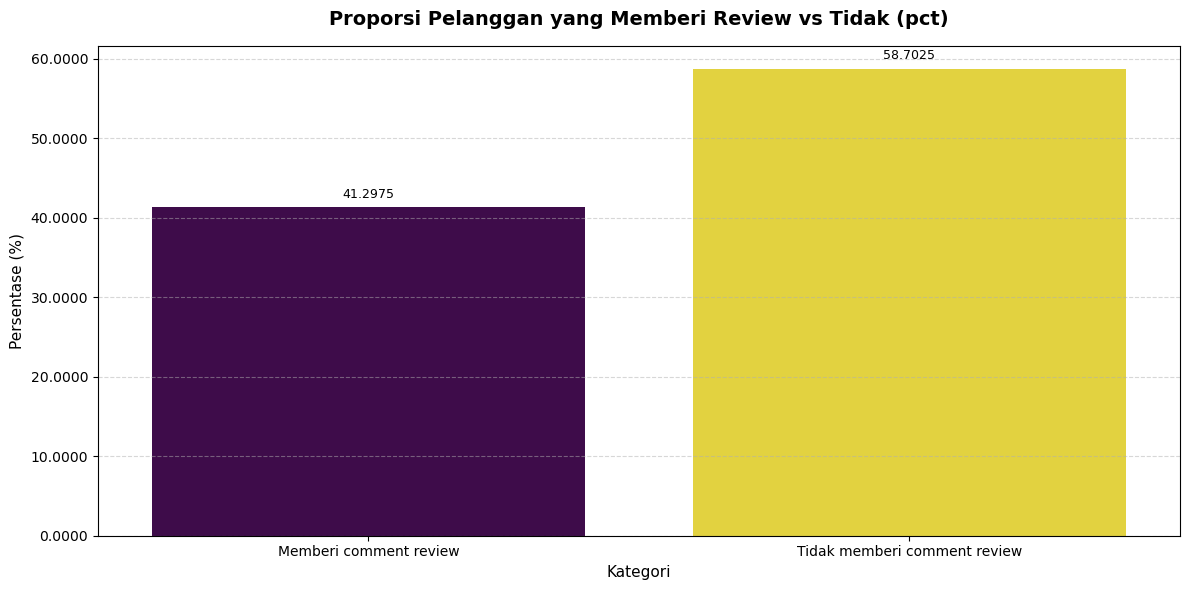

In [20]:
# 1. Mendefinisikan urutan score
Label = ['Memberi comment review', 'Tidak memberi comment review']

plt.figure(figsize=(12, 6))

# 2. Membuat Vertical Bar Plot dengan Gradient Warna (Palette)
ax = sns.barplot(
    data=data_q1_clean,
    x='label',              
    y='pct',   
    order=Label,
    palette='viridis',        # Menggunakan palette gradient (contoh: biru dari gelap ke terang)
    hue='pct',       # Ditambahkan agar palette berfungsi optimal di Seaborn terbaru
    legend=False              # Menyembunyikan legend karena hue hanya digunakan untuk warna
)

# 3. Menambahkan Label Angka di Atas Setiap Batang
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='{:,.4f}',      
        padding=5,          
        fontsize=9
    )

# 4. Mengatasi format angka pada sumbu Y
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.4f}'))

# 5. Judul dan Label Sumbu
plt.title('Proporsi Pelanggan yang Memberi Review vs Tidak (pct)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Kategori', fontsize=11)
plt.ylabel('Persentase (%)', fontsize=11)

# 6. Grid disesuaikan menjadi horizontal (sumbu Y)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout() 
plt.show()

#### KEY INSIGHT

1. sebanyak **58,7025%** tidak memberikan comment review, sedangkan **41,2975%** memberikan comment review

### 2. Apakah pelanggan dengan review score rendah (1–2) lebih cenderung menulis komentar?

In [21]:
data_q2 = order_review[['order_id','review_comment_message','review_score']]

In [22]:
#MEMBERI LABEL PADA REVIEW COMMENT MESSAGE
data_q2['label'] = np.where(data_q1['review_comment_message'].isna(), 'Tidak memberi comment review', 'Memberi comment review')
data_q2['review_score_category'] = np.where(data_q2['review_score'].isin([1, 2]),'Low Score','High Score')

C:\Users\adien\AppData\Local\Temp\ipykernel_8696\473977461.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_q2['label'] = np.where(data_q1['review_comment_message'].isna(), 'Tidak memberi comment review', 'Memberi comment review')
C:\Users\adien\AppData\Local\Temp\ipykernel_8696\473977461.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_q2['review_score_category'] = np.where(data_q2['review_score'].isin([1, 2]),'Low Score','High Score')


In [23]:
data_q2

,order_id,review_comment_message,review_score,label,review_score_category
0,73fc7af87114b39712e6da79b0a377eb,NaN,4,Tidak memberi comment review,High Score
1,a548910a1c6147796b98fdf73dbeba33,NaN,5,Tidak memberi comment review,High Score
2,f9e4b658b201a9f2ecdecbb34bed034b,NaN,5,Tidak memberi comment review,High Score
3,658677c97b385a9be170737859d3511b,Recebi bem antes do prazo estipulado.,5,Memberi comment review,High Score
4,8e6bfb81e283fa7e4f11123a3fb894f1,Parabéns lojas lannister adorei comprar pela I...,5,Memberi comment review,High Score
...,...,...,...,...,...
99219,2a8c23fee101d4d5662fa670396eb8da,NaN,5,Tidak memberi comment review,High Score
99220,22ec9f0669f784db00fa86d035cf8602,NaN,5,Tidak memberi comment review,High Score
99221,55d4004744368f5571d1f590031933e4,"Excelente mochila, entrega super rápida. Super...",5,Memberi comment review,High Score
99222,7725825d039fc1f0ceb7635e3f7d9206,NaN,4,Tidak memberi comment review,High Score


In [24]:
crosstab_q2 = pd.crosstab(
    data_q2['review_score_category'],
    data_q2['label']
)

In [25]:
crosstab_q2

label,Memberi comment review,Tidak memberi comment review
review_score_category,,
High Score,30087,54562
Low Score,10890,3685


In [26]:
crosstab_q2['Total'] = crosstab_q2.sum(axis=1)

crosstab_q2['% Memberi comment review'] = (
    crosstab_q2['Memberi comment review'] /
    crosstab_q2['Total'] * 100
).round(2)

crosstab_q2

label,Memberi comment review,Tidak memberi comment review,Total,% Memberi comment review
review_score_category,,,,
High Score,30087,54562,84649,35.54
Low Score,10890,3685,14575,74.72


In [27]:
crosstab_q2['% Tidak memberi comment review'] = (
    crosstab_q2['Tidak memberi comment review'] /
    crosstab_q2['Total'] * 100
).round(2)

crosstab_q2

label,Memberi comment review,Tidak memberi comment review,Total,% Memberi comment review,% Tidak memberi comment review
review_score_category,,,,,
High Score,30087,54562,84649,35.54,64.46
Low Score,10890,3685,14575,74.72,25.28


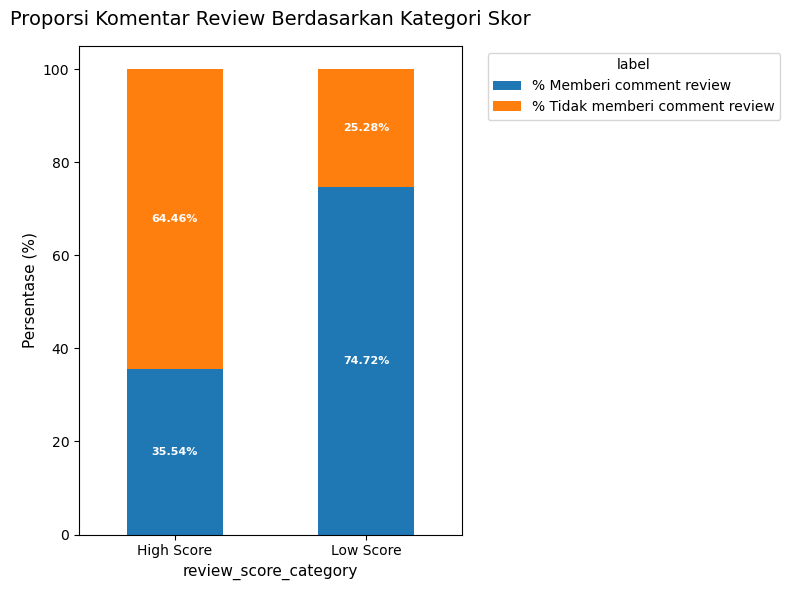

In [28]:
import matplotlib.pyplot as plt

# 1. Menentukan kolom persentase yang akan di-plot
cols_to_plot = ['% Memberi comment review', '% Tidak memberi comment review']

# 2. Membuat Stacked Bar Chart
ax = crosstab_q2[cols_to_plot].plot(
    kind='bar', 
    stacked=True, 
    figsize=(8, 6),
    color=['#1f77b4', '#ff7f0e'] 
)

# 3. Menambahkan angka di dalam bar dengan ukuran font lebih kecil
for container in ax.containers:
    ax.bar_label(
        container, 
        fmt='%.2f%%',          
        label_type='center',   
        color='white',         
        fontweight='bold',
        fontsize=8             # DIUBAH: Font diperkecil menjadi 8 agar tidak sesak
    )

plt.title('Proporsi Komentar Review Berdasarkan Kategori Skor', fontsize=14, pad=15)
plt.xlabel('review_score_category', fontsize=11)
plt.ylabel('Persentase (%)', fontsize=11)
plt.xticks(rotation=0)

# 4. Mengatur legend agar berada di LUAR grafik (sebelah kanan atas)
# Ini memastikan legend tidak akan menutupi balok data
plt.legend(title='label', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

#### KEY INSIGHT

Dari **99.224 review** yang dianalisis, sebanyak **84.649 review** termasuk kategori **High Score (3–5)** dan **14.575 review** termasuk **Low Score (1–2)**. Pada kategori Low Score, **74,72% review** disertai komentar, sedangkan pada High Score hanya **35,54%** yang disertai komentar.

### 3. Berapa rata-rata waktu antara order_delivered dan review_creation_date?

In [29]:
order_q3 = order[['order_id', 'order_delivered_customer_date']]
order_review_q3 = order_review[['order_id', 'review_creation_date']]

In [30]:
data_q3 = pd.merge(
    left = order_q3,
    right = order_review_q3,
    how = 'left',
    on = 'order_id'
)

In [31]:
## CHECKING NULL DATA
data_q3.isna().sum()

order_id                            0
order_delivered_customer_date    2987
review_creation_date              768
dtype: int64

**CATATAN:** Hasil `LEFT JOIN` antara tabel `orders` dan `order_reviews` menunjukkan terdapat **2.987 order** yang tidak memiliki `order_delivered_customer_date` dan **768 order** yang tidak memiliki `review_creation_date`. Karena kedua kolom tersebut diperlukan untuk menghitung waktu antara order diterima dan review dibuat, data dengan nilai missing pada kedua kolom tersebut tidak dapat digunakan dalam analisis Q3. Oleh karena itu, dilakukan treatment dengan **menghapus data tersebut khusus dari analisis Q3**.


In [32]:
## MENGHAPUS DATA YAN NULL
data_q3 = data_q3.dropna(
    subset=[
        'order_delivered_customer_date',
        'review_creation_date'
    ]
)

In [33]:
data_q3.isna().sum()

order_id                         0
order_delivered_customer_date    0
review_creation_date             0
dtype: int64

In [34]:
data_q3

,order_id,order_delivered_customer_date,review_creation_date
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-10 21:25:13,2017-10-11
1,53cdb2fc8bc7dce0b6741e2150273451,2018-08-07 15:27:45,2018-08-08
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-17 18:06:29,2018-08-18
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-12-02 00:28:42,2017-12-03
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-16 18:17:02,2018-02-17
...,...,...,...
99987,9c5dedf39a927c1b2549525ed64a053c,2017-03-17 15:08:01,2017-03-22
99988,63943bddc261676b46f01ca7ac2f7bd8,2018-02-28 17:37:56,2018-03-01
99989,83c1379a015df1e13d02aae0204711ab,2017-09-21 11:24:17,2017-09-22
99990,11c177c8e97725db2631073c19f07b62,2018-01-25 23:32:54,2018-01-26


**CATATAN:** Kolom `order_delivered_customer_date` memiliki informasi waktu hingga jam, menit, dan detik, sedangkan `review_creation_date` hanya tersedia pada level tanggal. Karena Q3 berfokus pada pengukuran **waktu dalam satuan hari** antara order diterima dan review dibuat, kedua kolom tanggal diseragamkan ke level **hari** dengan menghilangkan informasi waktu. Dengan demikian, perhitungan `review_waiting_days` dilakukan secara konsisten pada level hari.


In [35]:
data_q3['order_delivered_customer_date'] = pd.to_datetime(
    data_q3['order_delivered_customer_date']
).dt.normalize()


In [36]:
data_q3

,order_id,order_delivered_customer_date,review_creation_date
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-10,2017-10-11
1,53cdb2fc8bc7dce0b6741e2150273451,2018-08-07,2018-08-08
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-17,2018-08-18
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-12-02,2017-12-03
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-16,2018-02-17
...,...,...,...
99987,9c5dedf39a927c1b2549525ed64a053c,2017-03-17,2017-03-22
99988,63943bddc261676b46f01ca7ac2f7bd8,2018-02-28,2018-03-01
99989,83c1379a015df1e13d02aae0204711ab,2017-09-21,2017-09-22
99990,11c177c8e97725db2631073c19f07b62,2018-01-25,2018-01-26


In [37]:
data_q3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96359 entries, 0 to 99991
Data columns (total 3 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96359 non-null  object        
 1   order_delivered_customer_date  96359 non-null  datetime64[ns]
 2   review_creation_date           96359 non-null  datetime64[ns]
dtypes: datetime64[ns](2), object(1)
memory usage: 2.9+ MB


In [38]:
data_q3['date_diff'] = data_q3['review_creation_date'] - data_q3['order_delivered_customer_date'] 

In [39]:
data_q3

,order_id,order_delivered_customer_date,review_creation_date,date_diff
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-10,2017-10-11,1 days
1,53cdb2fc8bc7dce0b6741e2150273451,2018-08-07,2018-08-08,1 days
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-17,2018-08-18,1 days
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-12-02,2017-12-03,1 days
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-16,2018-02-17,1 days
...,...,...,...,...
99987,9c5dedf39a927c1b2549525ed64a053c,2017-03-17,2017-03-22,5 days
99988,63943bddc261676b46f01ca7ac2f7bd8,2018-02-28,2018-03-01,1 days
99989,83c1379a015df1e13d02aae0204711ab,2017-09-21,2017-09-22,1 days
99990,11c177c8e97725db2631073c19f07b62,2018-01-25,2018-01-26,1 days


In [40]:
data_q3['date_diff']

0       1 days
1       1 days
2       1 days
3       1 days
4       1 days
         ...  
99987   5 days
99988   1 days
99989   1 days
99990   1 days
99991   1 days
Name: date_diff, Length: 96359, dtype: timedelta64[ns]

In [41]:
# Ganti 'nama_kolom' dengan nama kolom yang berisi data hari tersebut
data_q3['date_diff'] = data_q3['date_diff'].dt.days

In [42]:
## Rata-rata waktu antara order_delivered dan review_creation_date
data_q3['date_diff'].mean()

0.4584211127139136

#### KEY INSIGHT

Rata-rata waktu antara order diterima oleh customer dan review dibuat adalah **0,4584 hari** atau sekitar **11 jam**.

## KEY FINDINGS

1. sebanyak **58,7025%** tidak memberikan comment review, sedangkan **41,2975%** memberikan comment review
2. Dari **99.224 review** yang dianalisis, sebanyak **84.649 review** termasuk kategori **High Score (3–5)** dan **14.575 review** termasuk **Low Score (1–2)**. Pada kategori Low Score, **74,72% review** disertai komentar, sedangkan pada High Score hanya **35,54%** yang disertai komentar.
3. Rata-rata waktu antara order diterima oleh customer dan review dibuat adalah **0,4584 hari** atau sekitar **11 jam**.

## BUSINESS IMPLICATION

1. Sebanyak **41,30% review** disertai komentar, komentar dapat dimanfaatkan untuk mengidentifikasi keluhan, apresiasi, dan area perbaikan yang tidak terlihat dari review score saja.
2. Proporsi komentar pada Low Score mencapai **74,72%**, sehingga komentar dari kelompok ini dapat menjadi sumber informasi penting untuk mengidentifikasi masalah pada produk, pengiriman, maupun pengalaman pelanggan.
3. Rata-rata review dibuat sekitar **11 jam** setelah order diterima, sehingga periode awal setelah pelanggan menerima order dapat menjadi waktu yang relevan untuk mendorong pelanggan memberikan feedback.
4. Review score memberikan gambaran kuantitatif, sedangkan komentar memberikan konteks mengenai alasan di balik penilaian pelanggan. Kombinasi keduanya dapat membantu bisnis menentukan area perbaikan secara lebih spesifik.